# Incremental Learning Strategies — All Warehouses & WorkCodes

Runs all five incremental learning strategies across OE, OF, and RT for every WorkCode.
N_BATCHES is set automatically based on data size.

**Run all cells top to bottom. Plots appear at the end.**

In [28]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from scipy import stats
from sklearn.metrics import mean_absolute_error, r2_score

import importlib
import feature_engineer
importlib.reload(feature_engineer)
from feature_engineer import get_engineered_df

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

PATH         = Path('~/Lucas_Systems_Capstone_Project/data/processed')
WAREHOUSES   = ['OE', 'OF', 'RT']
MAX_TIME     = 300
BLOCK_SIZE   = 50
RANDOM_STATE = 2026
UPDATE_TREES = 100

NOT_AVAILABLE = [
    'Travel_Distance',
    'same_aisle', 'same_lockey', 'same_location', 'same_level', 'diff_level',
    'time_of_day', 'day_of_week', 'hour',
]

XGB_PARAMS = dict(
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective='reg:tweedie',
    tweedie_variance_power=1.3,
    tree_method='hist',
    seed=RANDOM_STATE,
)

# Decay / window parameters
LAMBDA         = 0.02   # exponential decay rate
MAX_DECAY_DAYS = 90     # linear decay — zero weight beyond this
WINDOW_DAYS    = 60     # rolling window size
KS_THRESHOLD   = 0.05   # KS-test p-value threshold for drift
DRIFT_WEIGHT   = 0.3    # weight applied to pre-drift data
ADWIN_DELTA    = 0.002  # ADWIN sensitivity

try:
    from river import drift as river_drift
    ADWIN_AVAILABLE = True
    print('ADWIN available (river installed)')
except ImportError:
    ADWIN_AVAILABLE = False
    print('river not installed — ADWIN will be skipped. Run: pip install river')


ADWIN available (river installed)


In [29]:
def resolve_data_path(warehouse):
    return PATH / f'{warehouse.lower()}_detailed.parquet'


def load_engineered_data(warehouse, workcode, max_time=MAX_TIME):
    d, features_all, cat_cols_all = get_engineered_df(
        file_path=resolve_data_path(warehouse),
        warehouse=warehouse,
        max_time=max_time,
        work_code=workcode,
    )
    d = d.copy()
    d['Timestamp'] = pd.to_datetime(d['Timestamp'], errors='coerce')
    d = d.dropna(subset=['Timestamp']).copy()
    d['date']     = d['Timestamp'].dt.date
    d['WorkCode'] = d['WorkCode'].astype(str).str.replace('.0', '', regex=False)
    features = [f for f in features_all if f not in NOT_AVAILABLE]
    cat_cols = [c for c in cat_cols_all if c not in NOT_AVAILABLE]
    return d, features, cat_cols


def discover_workcodes(warehouse):
    df_raw = pd.read_parquet(resolve_data_path(warehouse))
    df_raw['WorkCode'] = df_raw['WorkCode'].astype(str).apply(
        lambda x: x.split('.')[0] if isinstance(x, str) else x
    )
    return sorted(df_raw['WorkCode'].dropna().unique().tolist())


def make_X_single(df, features, cat_cols, train_columns=None):
    X = pd.get_dummies(df[features], columns=cat_cols, drop_first=True)
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
    if train_columns is not None:
        X = X.reindex(columns=train_columns, fill_value=0)
    return X


def make_test_blocks(test_df, block_size=BLOCK_SIZE):
    d = test_df.sort_values(['UserID', 'Timestamp']).copy()
    blocks, block_rows = [], []
    for (uid, day), g in d.groupby(['UserID', 'date'], sort=False):
        g = g.sort_values('Timestamp').reset_index().rename(columns={'index': 'orig_index'}).copy()
        for start in range(0, len(g), block_size):
            chunk = g.iloc[start:start + block_size].copy()
            if len(chunk) < block_size: continue
            if chunk['WorkCode'].nunique() != 1: continue
            if (chunk['Time_Delta_sec'] > MAX_TIME).any(): continue
            block_id = f'{uid}_{day}_{start // block_size}'
            chunk['BlockID'] = block_id
            block_rows.append(chunk)
            blocks.append({
                'BlockID':     block_id,
                'UserID':      uid,
                'date':        day,
                'WorkCode':    chunk['WorkCode'].iloc[0],
                'n_tasks':     len(chunk),
                'actual_time': chunk['Time_Delta_sec'].sum(),
            })
    block_df      = pd.DataFrame(blocks)
    block_rows_df = pd.concat(block_rows, ignore_index=True) if block_rows else pd.DataFrame()
    return block_df, block_rows_df


def eval_blocks(test_df, preds_array, train_columns):
    test_df = test_df.copy().reset_index(drop=True)
    block_df, block_rows_df = make_test_blocks(test_df)
    if block_df.empty:
        return np.nan, np.nan, 0
    temp = test_df.copy().reset_index().rename(columns={'index': 'orig_index'})
    temp['pred'] = preds_array
    block_rows_df = block_rows_df.merge(temp[['orig_index', 'pred']], on='orig_index', how='left')
    block_pred = (
        block_rows_df.groupby('BlockID')
        .agg(actual_time=('Time_Delta_sec', 'sum'), pred=('pred', 'sum'))
        .reset_index()
    )
    mae = mean_absolute_error(block_pred['actual_time'], block_pred['pred'])
    r2  = r2_score(block_pred['actual_time'], block_pred['pred'])
    return mae / BLOCK_SIZE, r2, len(block_pred)


def make_split(df, features, cat_cols, n_batches):
    """Row-based chronological split. Returns train_df, batch_dfs, test_df, X_test, y_test, train_columns."""
    df = df.sort_values(['date', 'Timestamp']).reset_index(drop=True)
    n_rows  = len(df)
    n_train = int(n_rows * 0.60)
    n_test  = int(n_rows * 0.15)
    n_update = n_rows - n_train - n_test
    n_batch  = max(1, n_update // n_batches)

    train_df  = df.iloc[:n_train].copy().reset_index(drop=True)
    test_df   = df.iloc[n_train + n_update:].copy().reset_index(drop=True)
    batch_dfs = [
        df.iloc[n_train + i*n_batch : n_train + (i+1)*n_batch].copy().reset_index(drop=True)
        for i in range(n_batches)
    ]
    # Drop any empty batches
    batch_dfs = [b for b in batch_dfs if len(b) > 0]

    X_train_init  = make_X_single(train_df, features, cat_cols)
    train_columns = X_train_init.columns.tolist()
    X_test        = make_X_single(test_df, features, cat_cols, train_columns=train_columns)
    y_test        = test_df['Time_Delta_sec'].astype(float)

    return train_df, batch_dfs, test_df, X_train_init, X_test, y_test, train_columns


def exponential_weights(df, reference_date, lam=LAMBDA):
    days_old = (pd.Timestamp(reference_date) - pd.to_datetime(df['date'])).dt.days.clip(lower=0)
    return np.exp(-lam * days_old).values


def linear_weights(df, reference_date, max_days=MAX_DECAY_DAYS):
    days_old = (pd.Timestamp(reference_date) - pd.to_datetime(df['date'])).dt.days.clip(lower=0)
    return np.clip(1 - days_old / max_days, 0, 1).values


In [30]:
# ── Main loop — runs all strategies for all warehouses and WorkCodes ──────
# all_results[warehouse][workcode] = dict of strategy -> list of MAE/task
all_results = {}

for warehouse in WAREHOUSES:
    all_results[warehouse] = {}
    workcodes = discover_workcodes(warehouse)
    print(f'\n{"="*60}')
    print(f'WAREHOUSE: {warehouse} | WorkCodes: {workcodes}')
    print(f'{"="*60}')

    for wc in workcodes:
        print(f'\n  ── WorkCode {wc} ──')

        try:
            df, features, cat_cols = load_engineered_data(warehouse, wc)
        except Exception as e:
            print(f'  Could not load WC {wc}: {e} — skipping')
            continue

        if len(df) < 500:
            print(f'  Too few rows ({len(df)}) — skipping')
            continue

        # Auto-set N_BATCHES based on data size
        n_rows    = len(df)
        n_batches = max(3, min(16, int(n_rows * 0.25 / 1000)))
        print(f'  Rows: {n_rows:,} | N_BATCHES: {n_batches}')

        train_df, batch_dfs, test_df, X_train_init, X_test, y_test, train_columns = make_split(
            df, features, cat_cols, n_batches
        )
        actual_batches = len(batch_dfs)
        dtest  = xgb.DMatrix(X_test)
        dtrain = xgb.DMatrix(X_train_init, label=train_df['Time_Delta_sec'].astype(float))

        results = {}

        # ── Baseline ──────────────────────────────────────────────────────
        model_base = xgb.train(XGB_PARAMS, dtrain, num_boost_round=1200, verbose_eval=False)
        preds = model_base.predict(dtest)
        mae0, _, _ = eval_blocks(test_df, preds, train_columns)
        results['Baseline'] = [mae0] * (actual_batches + 1)

        # ── Naive update ──────────────────────────────────────────────────
        model = xgb.train(XGB_PARAMS, dtrain, num_boost_round=1200, verbose_eval=False)
        preds = model.predict(dtest)
        mae, _, _ = eval_blocks(test_df, preds, train_columns)
        naive_maes = [mae]
        for batch_df in batch_dfs:
            X_b = make_X_single(batch_df, features, cat_cols, train_columns=train_columns)
            y_b = batch_df['Time_Delta_sec'].astype(float)
            model = xgb.train(XGB_PARAMS, xgb.DMatrix(X_b, label=y_b),
                              num_boost_round=UPDATE_TREES, xgb_model=model, verbose_eval=False)
            mae, _, _ = eval_blocks(test_df, model.predict(dtest), train_columns)
            naive_maes.append(mae)
        results['Naive update'] = naive_maes

        # ── Exponential decay ─────────────────────────────────────────────
        model   = xgb.train(XGB_PARAMS, dtrain, num_boost_round=1200, verbose_eval=False)
        preds   = model.predict(dtest)
        mae, _, _ = eval_blocks(test_df, preds, train_columns)
        exp_maes  = [mae]
        seen_df   = train_df.copy()
        for batch_df in batch_dfs:
            seen_df = pd.concat([seen_df, batch_df], ignore_index=True)
            ref     = seen_df['date'].max()
            X_s     = make_X_single(seen_df, features, cat_cols, train_columns=train_columns)
            y_s     = seen_df['Time_Delta_sec'].astype(float)
            w_s     = exponential_weights(seen_df, ref)
            model   = xgb.train(XGB_PARAMS, xgb.DMatrix(X_s, label=y_s, weight=w_s),
                                num_boost_round=UPDATE_TREES, xgb_model=model, verbose_eval=False)
            mae, _, _ = eval_blocks(test_df, model.predict(dtest), train_columns)
            exp_maes.append(mae)
        results['Exp decay'] = exp_maes

        # ── Linear decay ──────────────────────────────────────────────────
        model   = xgb.train(XGB_PARAMS, dtrain, num_boost_round=1200, verbose_eval=False)
        preds   = model.predict(dtest)
        mae, _, _ = eval_blocks(test_df, preds, train_columns)
        lin_maes  = [mae]
        seen_df   = train_df.copy()
        for batch_df in batch_dfs:
            seen_df = pd.concat([seen_df, batch_df], ignore_index=True)
            ref     = seen_df['date'].max()
            X_s     = make_X_single(seen_df, features, cat_cols, train_columns=train_columns)
            y_s     = seen_df['Time_Delta_sec'].astype(float)
            w_s     = linear_weights(seen_df, ref)
            model   = xgb.train(XGB_PARAMS, xgb.DMatrix(X_s, label=y_s, weight=w_s),
                                num_boost_round=UPDATE_TREES, xgb_model=model, verbose_eval=False)
            mae, _, _ = eval_blocks(test_df, model.predict(dtest), train_columns)
            lin_maes.append(mae)
        results['Linear decay'] = lin_maes

        # ── Rolling window ────────────────────────────────────────────────
        model    = xgb.train(XGB_PARAMS, dtrain, num_boost_round=1200, verbose_eval=False)
        preds    = model.predict(dtest)
        mae, _, _ = eval_blocks(test_df, preds, train_columns)
        roll_maes = [mae]
        seen_df   = train_df.copy()
        for batch_df in batch_dfs:
            seen_df  = pd.concat([seen_df, batch_df], ignore_index=True)
            cutoff   = pd.Timestamp(seen_df['date'].max()) - pd.Timedelta(days=WINDOW_DAYS)
            window   = seen_df[pd.to_datetime(seen_df['date']) >= cutoff].copy()
            X_w      = make_X_single(window, features, cat_cols, train_columns=train_columns)
            y_w      = window['Time_Delta_sec'].astype(float)
            model    = xgb.train(XGB_PARAMS, xgb.DMatrix(X_w, label=y_w),
                                 num_boost_round=UPDATE_TREES, xgb_model=model, verbose_eval=False)
            mae, _, _ = eval_blocks(test_df, model.predict(dtest), train_columns)
            roll_maes.append(mae)
        results['Rolling window'] = roll_maes

        # ── KS-test drift ─────────────────────────────────────────────────
        model    = xgb.train(XGB_PARAMS, dtrain, num_boost_round=1200, verbose_eval=False)
        preds    = model.predict(dtest)
        mae, _, _ = eval_blocks(test_df, preds, train_columns)
        ks_maes   = [mae]
        ref_dist  = train_df['Time_Delta_sec'].dropna().values
        seen_df   = train_df.copy()
        for batch_df in batch_dfs:
            _, p = stats.ks_2samp(ref_dist, batch_df['Time_Delta_sec'].dropna().values)
            seen_df = pd.concat([seen_df, batch_df], ignore_index=True)
            X_s     = make_X_single(seen_df, features, cat_cols, train_columns=train_columns)
            y_s     = seen_df['Time_Delta_sec'].astype(float)
            if p < KS_THRESHOLD:
                batch_dates = set(batch_df['date'].unique())
                w_s = np.where(seen_df['date'].isin(batch_dates), 1.0, DRIFT_WEIGHT)
            else:
                w_s = np.ones(len(seen_df))
            model   = xgb.train(XGB_PARAMS, xgb.DMatrix(X_s, label=y_s, weight=w_s),
                                num_boost_round=UPDATE_TREES, xgb_model=model, verbose_eval=False)
            mae, _, _ = eval_blocks(test_df, model.predict(dtest), train_columns)
            ks_maes.append(mae)
        results['KS-test drift'] = ks_maes

        # ── ADWIN drift ───────────────────────────────────────────────────
        if ADWIN_AVAILABLE:
            model    = xgb.train(XGB_PARAMS, dtrain, num_boost_round=1200, verbose_eval=False)
            preds    = model.predict(dtest)
            mae, _, _ = eval_blocks(test_df, preds, train_columns)
            adwin_maes = [mae]
            adwin      = river_drift.ADWIN(delta=ADWIN_DELTA)
            train_errs = np.abs(train_df['Time_Delta_sec'].values - model.predict(xgb.DMatrix(X_train_init)))
            for err in train_errs:
                adwin.update(err)
            seen_df = train_df.copy()
            for batch_df in batch_dfs:
                X_b    = make_X_single(batch_df, features, cat_cols, train_columns=train_columns)
                b_errs = np.abs(batch_df['Time_Delta_sec'].values - model.predict(xgb.DMatrix(X_b)))
                drift_detected = False
                for err in b_errs:
                    adwin.update(err)
                    if adwin.drift_detected:
                        drift_detected = True
                        break
                seen_df = pd.concat([seen_df, batch_df], ignore_index=True)
                X_s     = make_X_single(seen_df, features, cat_cols, train_columns=train_columns)
                y_s     = seen_df['Time_Delta_sec'].astype(float)
                if drift_detected:
                    batch_dates = set(batch_df['date'].unique())
                    w_s = np.where(seen_df['date'].isin(batch_dates), 1.0, DRIFT_WEIGHT)
                else:
                    w_s = np.ones(len(seen_df))
                model   = xgb.train(XGB_PARAMS, xgb.DMatrix(X_s, label=y_s, weight=w_s),
                                    num_boost_round=UPDATE_TREES, xgb_model=model, verbose_eval=False)
                mae, _, _ = eval_blocks(test_df, model.predict(dtest), train_columns)
                adwin_maes.append(mae)
            results['ADWIN drift'] = adwin_maes

        all_results[warehouse][wc] = results
        best = min(results.items(), key=lambda x: x[1][-1])
        print(f'  Done. Best at final batch: {best[0]} ({best[1][-1]:.3f}s)')

print('\n\nAll done.')



WAREHOUSE: OE | WorkCodes: ['10', '20', '30']

  ── WorkCode 10 ──
  Rows: 4,082 | N_BATCHES: 3
  Done. Best at final batch: Linear decay (23.391s)

  ── WorkCode 20 ──
  Rows: 21,334 | N_BATCHES: 5
  Done. Best at final batch: Rolling window (7.358s)

  ── WorkCode 30 ──
  Rows: 65,298 | N_BATCHES: 16
  Done. Best at final batch: Rolling window (6.640s)

WAREHOUSE: OF | WorkCodes: ['10', '20', '30']

  ── WorkCode 10 ──
  Rows: 4,676 | N_BATCHES: 3
  Done. Best at final batch: Exp decay (13.080s)

  ── WorkCode 20 ──
  Rows: 40,138 | N_BATCHES: 10
  Done. Best at final batch: Baseline (10.253s)

  ── WorkCode 30 ──
  Rows: 75,458 | N_BATCHES: 16
  Done. Best at final batch: Baseline (10.252s)

WAREHOUSE: RT | WorkCodes: ['1', '11', '13', '14', '15', '2', '3', '4', '5', '6', 'nan']

  ── WorkCode 1 ──
  Too few rows (0) — skipping

  ── WorkCode 11 ──
  Too few rows (0) — skipping

  ── WorkCode 13 ──
  Too few rows (0) — skipping

  ── WorkCode 14 ──
  Too few rows (0) — skipping

  

In [31]:
all_results

{'OE': {'10': {'Baseline': [24.95134321986607,
    24.95134321986607,
    24.95134321986607,
    24.95134321986607],
   'Naive update': [24.95134321986607,
    18.363101322544644,
    22.632044949776787,
    24.85402458147321],
   'Exp decay': [24.95134321986607,
    23.111964034598213,
    23.220945619419645,
    23.57518599330357],
   'Linear decay': [24.95134321986607,
    23.114499609375002,
    23.101066294642855,
    23.390950502232144],
   'Rolling window': [24.95134321986607,
    22.466385770089286,
    22.935340848214288,
    23.489295926339288],
   'KS-test drift': [24.95134321986607,
    22.634055970982146,
    23.454553320312503,
    24.362440457589287],
   'ADWIN drift': [24.95134321986607,
    22.634055970982146,
    23.980375027901786,
    24.322160044642857]},
  '20': {'Baseline': [8.678918525390626,
    8.678918525390626,
    8.678918525390626,
    8.678918525390626,
    8.678918525390626,
    8.678918525390626],
   'Naive update': [8.678918525390626,
    7.54853851740

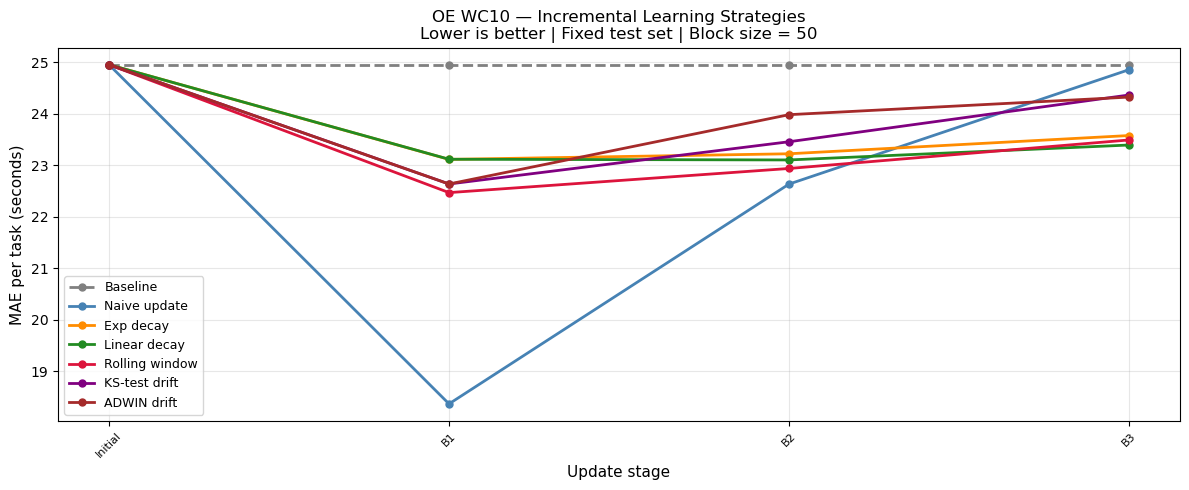


OE WC10 — Final MAE/task:
  Linear decay         initial=24.951s  final=23.391s  ↓
  Rolling window       initial=24.951s  final=23.489s  ↓
  Exp decay            initial=24.951s  final=23.575s  ↓
  ADWIN drift          initial=24.951s  final=24.322s  ↓
  KS-test drift        initial=24.951s  final=24.362s  ↓
  Naive update         initial=24.951s  final=24.854s  ↓
  Baseline             initial=24.951s  final=24.951s  ↑



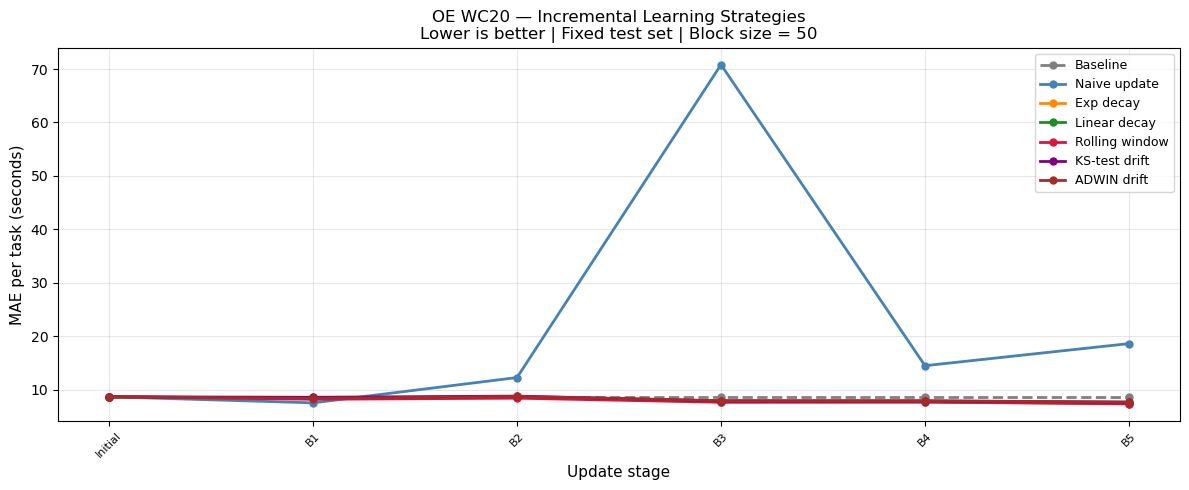


OE WC20 — Final MAE/task:
  Rolling window       initial=8.679s  final=7.358s  ↓
  Linear decay         initial=8.679s  final=7.422s  ↓
  Exp decay            initial=8.679s  final=7.531s  ↓
  KS-test drift        initial=8.679s  final=7.670s  ↓
  ADWIN drift          initial=8.679s  final=7.695s  ↓
  Baseline             initial=8.679s  final=8.679s  ↑
  Naive update         initial=8.679s  final=18.629s  ↑



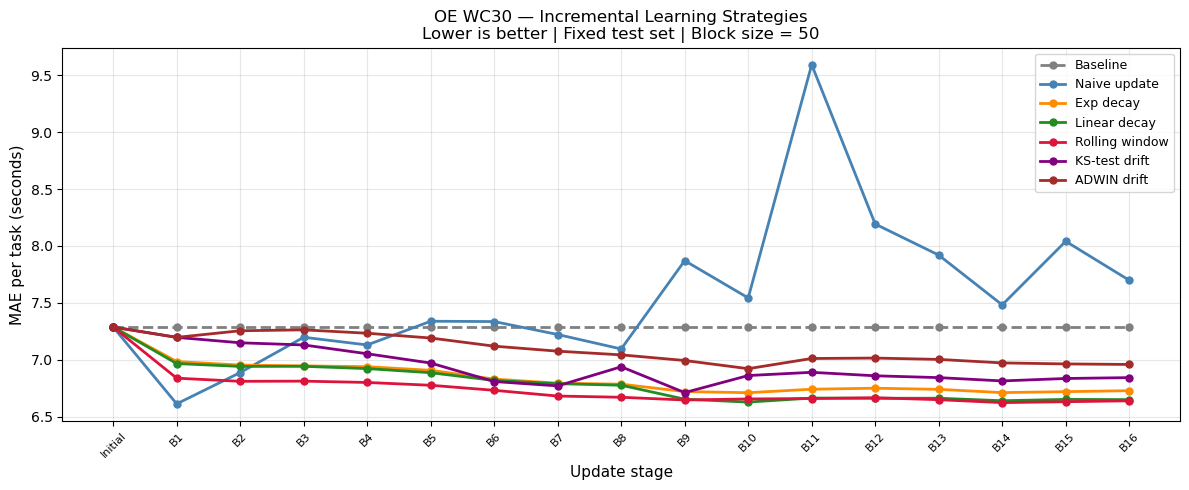


OE WC30 — Final MAE/task:
  Rolling window       initial=7.288s  final=6.640s  ↓
  Linear decay         initial=7.288s  final=6.651s  ↓
  Exp decay            initial=7.288s  final=6.729s  ↓
  KS-test drift        initial=7.288s  final=6.844s  ↓
  ADWIN drift          initial=7.288s  final=6.960s  ↓
  Baseline             initial=7.288s  final=7.288s  ↑
  Naive update         initial=7.288s  final=7.699s  ↑



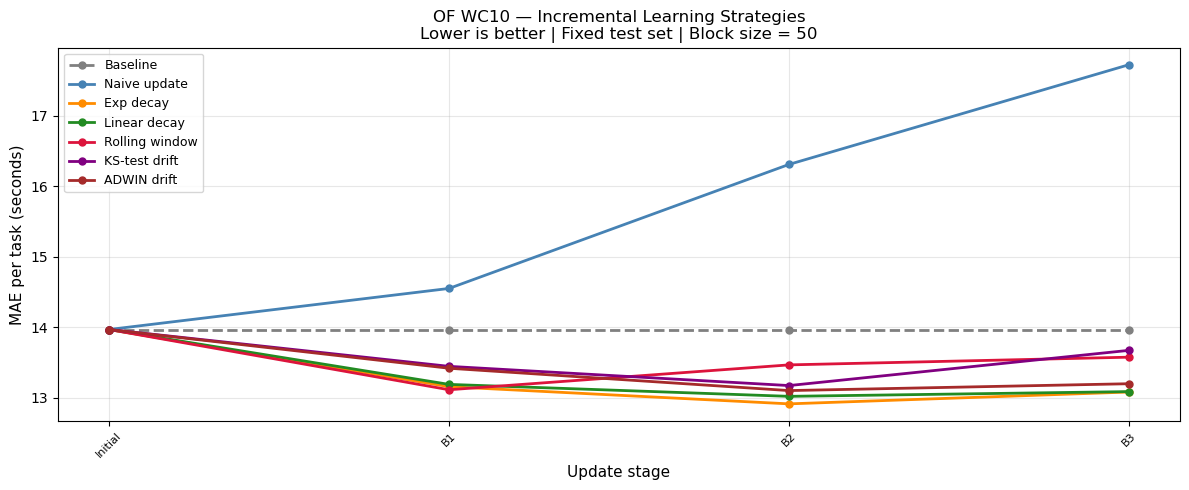


OF WC10 — Final MAE/task:
  Exp decay            initial=13.967s  final=13.080s  ↓
  Linear decay         initial=13.967s  final=13.086s  ↓
  ADWIN drift          initial=13.967s  final=13.198s  ↓
  Rolling window       initial=13.967s  final=13.575s  ↓
  KS-test drift        initial=13.967s  final=13.672s  ↓
  Baseline             initial=13.967s  final=13.967s  ↑
  Naive update         initial=13.967s  final=17.729s  ↑



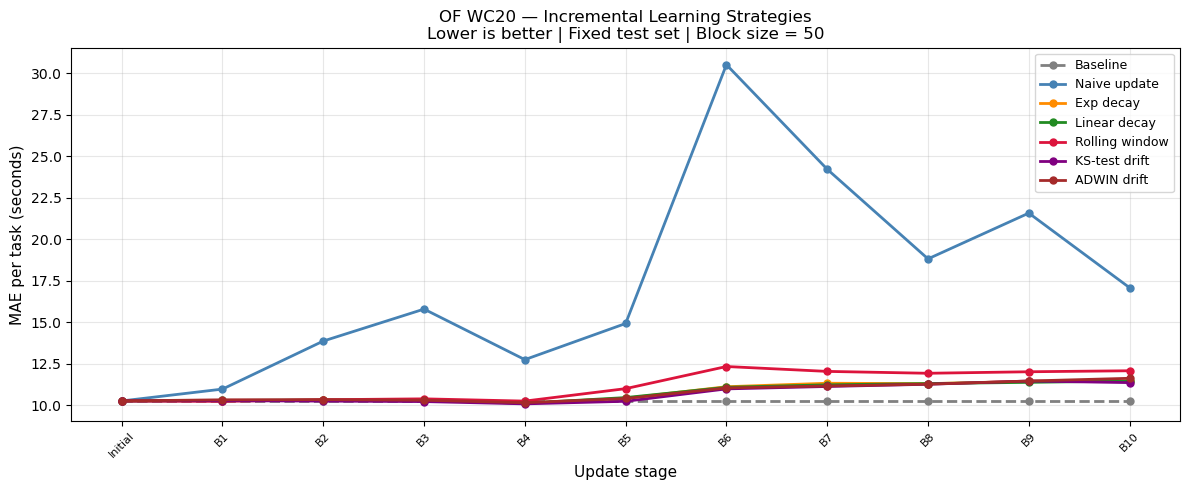


OF WC20 — Final MAE/task:
  Baseline             initial=10.253s  final=10.253s  ↑
  KS-test drift        initial=10.253s  final=11.357s  ↑
  Linear decay         initial=10.253s  final=11.454s  ↑
  Exp decay            initial=10.253s  final=11.462s  ↑
  ADWIN drift          initial=10.253s  final=11.618s  ↑
  Rolling window       initial=10.253s  final=12.072s  ↑
  Naive update         initial=10.253s  final=17.078s  ↑



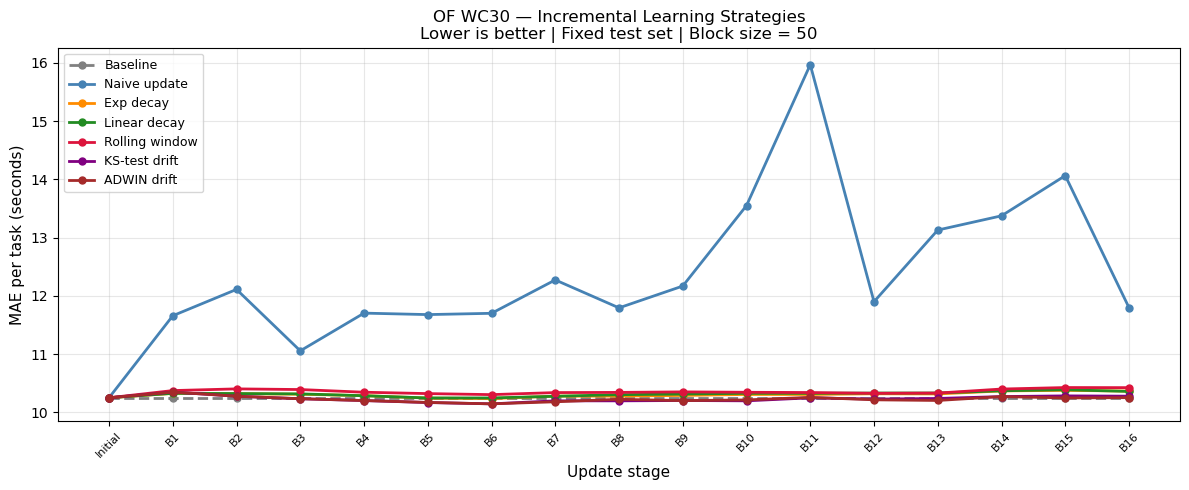


OF WC30 — Final MAE/task:
  Baseline             initial=10.252s  final=10.252s  ↑
  ADWIN drift          initial=10.252s  final=10.254s  ↑
  KS-test drift        initial=10.252s  final=10.280s  ↑
  Linear decay         initial=10.252s  final=10.361s  ↑
  Exp decay            initial=10.252s  final=10.367s  ↑
  Rolling window       initial=10.252s  final=10.426s  ↑
  Naive update         initial=10.252s  final=11.799s  ↑



In [32]:
# ── One comparison plot per warehouse/WorkCode combo ─────────────────────
COLORS = {
    'Baseline':       'gray',
    'Naive update':   'steelblue',
    'Exp decay':      'darkorange',
    'Linear decay':   'forestgreen',
    'Rolling window': 'crimson',
    'KS-test drift':  'purple',
    'ADWIN drift':    'brown',
}

for warehouse, wc_results in all_results.items():
    for wc, results in wc_results.items():
        if not results:
            continue

        n_points = max(len(v) for v in results.values())
        labels   = ['Initial'] + [f'B{i+1}' for i in range(n_points - 1)]

        fig, ax = plt.subplots(figsize=(12, 5))

        for strategy, maes in results.items():
            ax.plot(
                range(len(maes)), maes,
                marker='o', linewidth=2, markersize=5,
                label=strategy,
                color=COLORS.get(strategy, 'black'),
                linestyle='--' if strategy == 'Baseline' else '-'
            )

        ax.set_xticks(range(n_points))
        ax.set_xticklabels(labels, rotation=45, fontsize=8)
        ax.set_xlabel('Update stage', fontsize=11)
        ax.set_ylabel('MAE per task (seconds)', fontsize=11)
        ax.set_title(
            f'{warehouse} WC{wc} — Incremental Learning Strategies\n'
            f'Lower is better | Fixed test set | Block size = {BLOCK_SIZE}',
            fontsize=12
        )
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Summary table
        print(f'\n{warehouse} WC{wc} — Final MAE/task:')
        for strategy, maes in sorted(results.items(), key=lambda x: x[1][-1]):
            trend = '↓' if maes[-1] < maes[0] else '↑'
            print(f'  {strategy:<20} initial={maes[0]:.3f}s  final={maes[-1]:.3f}s  {trend}')
        print()
